# KNearestNeighbors (KNN)🦆

> If it looks like a duck, swims like a duck, and quacks like a duck, then it probably is a duck.


In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score

### 1. Učitavanje i analiza skupa podataka

Koristimo skup podataka [Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)).

In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
data = load_breast_cancer()

In [4]:
type(data)

sklearn.utils._bunch.Bunch

<code>Bunch</code> je scikit-learn verzija Pandas tipa <code>DataFrame</code> za rad sa tabelarnim podacima. Objekti tipa <code>Bunch</code> imaju atribute za dobijanje raznih karakteristika skupa podataka koje čuvaju.

Više informacija o učitanom skupu podataka možemo dobiti pomoću atributa <code>DESCR</code>.

In [5]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

Iz opisa vidimo da skup podataka raspolaze sa 30 ulaznih atributa koji su numerickog tipa. Njihove nazive mozemo izdvojiti pomoću <code>feature_names</code> polja <code>Bunch</code> objekta. Vrednostima ulaznih atributa možemo pristupiti pomoću polja <code>data</code>, dok su vrednosti ciljnog atributa dostupni kroz polje <code>target</code>.

In [6]:
data.data        

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [7]:
data.target                

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [8]:
data.feature_names           

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [9]:
data.target_names             #nazivi ciljnog atributa (nazivi klasa)

array(['malignant', 'benign'], dtype='<U9')

### 2. Podela na ulazne i ciljne atribute

Da bismo mogli da koristimo funkcije i metode Pandas biblioteke za analizu podataka, preći ćemo na <code>DataFrame</code> strukture podataka.

In [10]:
X = pd.DataFrame(data.data, columns=data.feature_names)
Y = pd.DataFrame(data.target, columns=['diagnosis'])

Prikazati ulazne atribute za prvih nekoliko instanci kao i dimenzije skupa podataka.

In [11]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [12]:
X.shape

(569, 30)

**NAPOMENA:** U odnosu na skup podataka koji smo koristili na prošlom času (<code>data.csv</code>) fale kolone <code>id</code>, <code>diagnosis</code> i <code>Unnamed: 32</code>. Ono sto je njima u koloni <code>diagnosis</code> ovde imamo u <code>data.target</code>, dok druge dve kolone nisu relevantne. Broj instanci je isti.

### 3. Pretprocesiranje ulaznih atributa

Prikazati deskriptivne statistike ulaznih atributa:

In [13]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Na osnovu statistika kolona možemo primetiti da se vrednosti nalaze u različitim rasponima.

Pitanja na koja bi trebalo da odogovorimo su:
1. Da li je potrebno izvršiti normalizaciju prilikom korišćenja KNN? (Da, zašto?)
2. Da li je KNN robusan na autlajere? (Ne, zašto?)

### 3.1. Rad sa elementima van granica

Pošto želimo da noramlizujemo podatke na raspon [0, 1], prvo je potrebno proveriti da li postoje elementi van granica, i kako bi oni uticali na normalizaciju naših podataka (Pogledajte svesku o normalizaciji).
Takođe, model *KNN* je osetljiv na elemente van granica, što predstavlja još jedan motiv provere.


#### 3.1.1 Provera da li u skupu postoje elementi van granica

Postoji veliki broj metoda za detekciju elemenata van granica:
* Boxplot 
* Histogram
* Mean and Standard Deviation
* IQR (Inter Quartile Range)
* Z-score
* Percentile

U ovom zadatku ćemo iskoristiti IQR. Za domaći istražite ostale metode.

Funkcija <code>IQR</code> računa interkvartlano rastojanje. Kao povratnu vrednost čuvamo broj autlajera koji su manji od donje granice ili veći od gornje granice, kao i procenat podataka po kolonama koji su van granica.

In [14]:
X['mean radius'].quantile()      #default za 0.5 - medijana

13.37

In [15]:
X['mean radius'].quantile([0.25, 0.75])   

0.25    11.70
0.75    15.78
Name: mean radius, dtype: float64

In [16]:
def IQR(data, feature_names):
    
    iqr_results = pd.DataFrame(0, dtype='float64', index=feature_names, 
                               columns=['min', 'lower', 'num_below_lower', 
                                        'max', 'upper', 'num_above_upper', 'percantage']) 
    for name in feature_names:
        (Q1, Q3) = data[name].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        
        upper = Q3 + (1.5 * IQR)                             #leva granična vrednost
        lower = Q1 - (1.5 * IQR)                             #desna granična vrednost      
        iqr_results.loc[name, 'upper'] = upper
        iqr_results.loc[name, 'lower'] = lower

        num_below_lower = (data[name] < lower).sum()            #number of instances below lower bound
        num_above_upper = (data[name] > upper).sum()            #number of instances above upper bound
        iqr_results.loc[name, 'num_below_lower'] = num_below_lower
        iqr_results.loc[name, 'num_above_upper'] = num_above_upper
        
        percentage = round((num_below_lower + num_above_upper) / data.shape[0] * 100)
        iqr_results.loc[name, 'percantage']  = percentage
        
        iqr_results.loc[name, 'min'], iqr_results.loc[name, 'max'] = data[name].min(), data[name].max()  
        
    return iqr_results

❓ _Pitanje_:  Da li proveru elemenata van granica i normalizaciju vršimo pre podele na trening i test skup?

**Nakon, inače smo kompromitovali test skup.**

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, stratify=Y, random_state=29)

In [18]:
iqr_results = IQR(X_train, X_train.columns)
iqr_results

,min,lower,num_below_lower,max,upper,num_above_upper,percantage
mean radius,7.760000,5.676250,0.0,28.11000,21.786250,11.0,3.0
mean texture,10.380000,7.821250,0.0,39.28000,30.131250,5.0,1.0
mean perimeter,47.920000,32.293750,0.0,188.50000,146.543750,12.0,3.0
mean area,181.000000,-101.550000,0.0,2501.00000,1293.650000,24.0,6.0
mean smoothness,0.052630,0.056550,1.0,0.14470,0.135430,2.0,1.0
mean compactness,0.019380,-0.038431,0.0,0.34540,0.231859,11.0,3.0
mean concavity,0.000000,-0.128531,0.0,0.42680,0.294119,13.0,3.0
mean concave points,0.000000,-0.064485,0.0,0.20120,0.161775,5.0,1.0
mean symmetry,0.106000,0.111512,1.0,0.30400,0.246213,10.0,3.0
mean fractal dimension,0.049960,0.046497,0.0,0.09575,0.077878,15.0,4.0


Dakle, možemo zaključiti da postoje autlajeri, ali ih nema mnogo i vrednosti ne odskaču previše.

#### 3.1.2 Metode za rad sa autlajerima

Ukoliko smatramo da će autlajeri previše uticati na model možemo primeniti neku od sledećih tehnika:
* Uklanjanje autlajera 
* Odsecanje - svi autlajeri se slikaju u granične vrednosti
* Postavljanje na *NaN* + primena neke metode za rad sa nedostajućim vrednostima

Mi ćemo npr. odabrati tehniku odsecanje vrednosti.

In [19]:
X_train.clip(lower=iqr_results['lower'], upper=iqr_results['upper'], axis=1, inplace=True)

Provera da li je odsecanje vrednosti realizovano nad kolonama (može se videti iz kolona <code>min</code> i <code>max</code>).

In [20]:
X_train.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,...,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000
mean,14.062314,19.220742,91.559871,637.417371,0.096222,0.103292,0.088098,0.049108,0.180454,0.062554,...,16.204234,25.600381,106.849941,851.949853,0.131758,0.250832,0.271273,0.115254,0.287977,0.083334
std,3.319965,4.133141,22.989766,301.000956,0.013886,0.050207,0.076500,0.038623,0.025836,0.006230,...,4.607828,6.035673,32.083583,479.125958,0.022601,0.143440,0.200430,0.065804,0.054740,0.015892
min,7.760000,10.380000,47.920000,181.000000,0.056550,0.019380,0.000000,0.000000,0.111512,0.049960,...,8.952000,12.490000,56.650000,240.100000,0.071170,0.027290,0.000000,0.000000,0.156600,0.055210
25%,11.717500,16.187500,75.137500,421.650000,0.086130,0.062927,0.029962,0.020362,0.162025,0.058265,...,13.010000,21.085000,84.012500,514.325000,0.115300,0.144650,0.114975,0.064345,0.251000,0.071557
50%,13.275000,18.865000,85.980000,545.650000,0.096565,0.090505,0.058770,0.033335,0.178950,0.061685,...,14.965000,25.370000,97.620000,684.550000,0.131250,0.215700,0.224800,0.098855,0.282800,0.080195
75%,15.745000,21.765000,103.700000,770.450000,0.105850,0.130500,0.135625,0.076927,0.195700,0.066110,...,18.805000,29.610000,125.325000,1087.000000,0.145900,0.342575,0.390550,0.166200,0.318625,0.092218
max,21.786250,30.131250,146.543750,1293.650000,0.135430,0.231859,0.294119,0.161775,0.246213,0.077878,...,27.497500,42.397500,187.293750,1946.012500,0.191800,0.639462,0.803913,0.291000,0.420063,0.123208


🤔 **_DOMAĆI_**: Isprobati preostale tehnika i uporedite dobijene modele:
 - Koja od tehnika Vam se čini najbolja?
 - Sa obzirom na to da nema mnogo autlajera, čini se da bi sve tehnike mogle da budu odgovarajuće.
 - Pošto radimo sa atributima veličina, prečnik, simetrija itd. mase za koju se vrši klasifikacija u benigni/maligni karcinom, možda baš ekstremne vrednosti signaliziraju postojanje maligniteta? 

### 3.2. Normalizacija
Za normalizaciju ćemo iskoristiti <code>MinMaxScaler</code>. Vrednosti *min* i *max* ćemo odrediti na osnovu trening skupa, a zatim primeniti transformaciju i na trening i na test skup.
Ponovo naglašavamo, **neophodno je da podelu na test i trening izvršimo pre normalizacije!**

In [21]:
from sklearn.preprocessing import MinMaxScaler

In [22]:
scaler = MinMaxScaler()

In [23]:
scaler.fit(X_train)

MinMaxScaler()

In [24]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

#### Vizuelna provera normalizovanosti podataka 

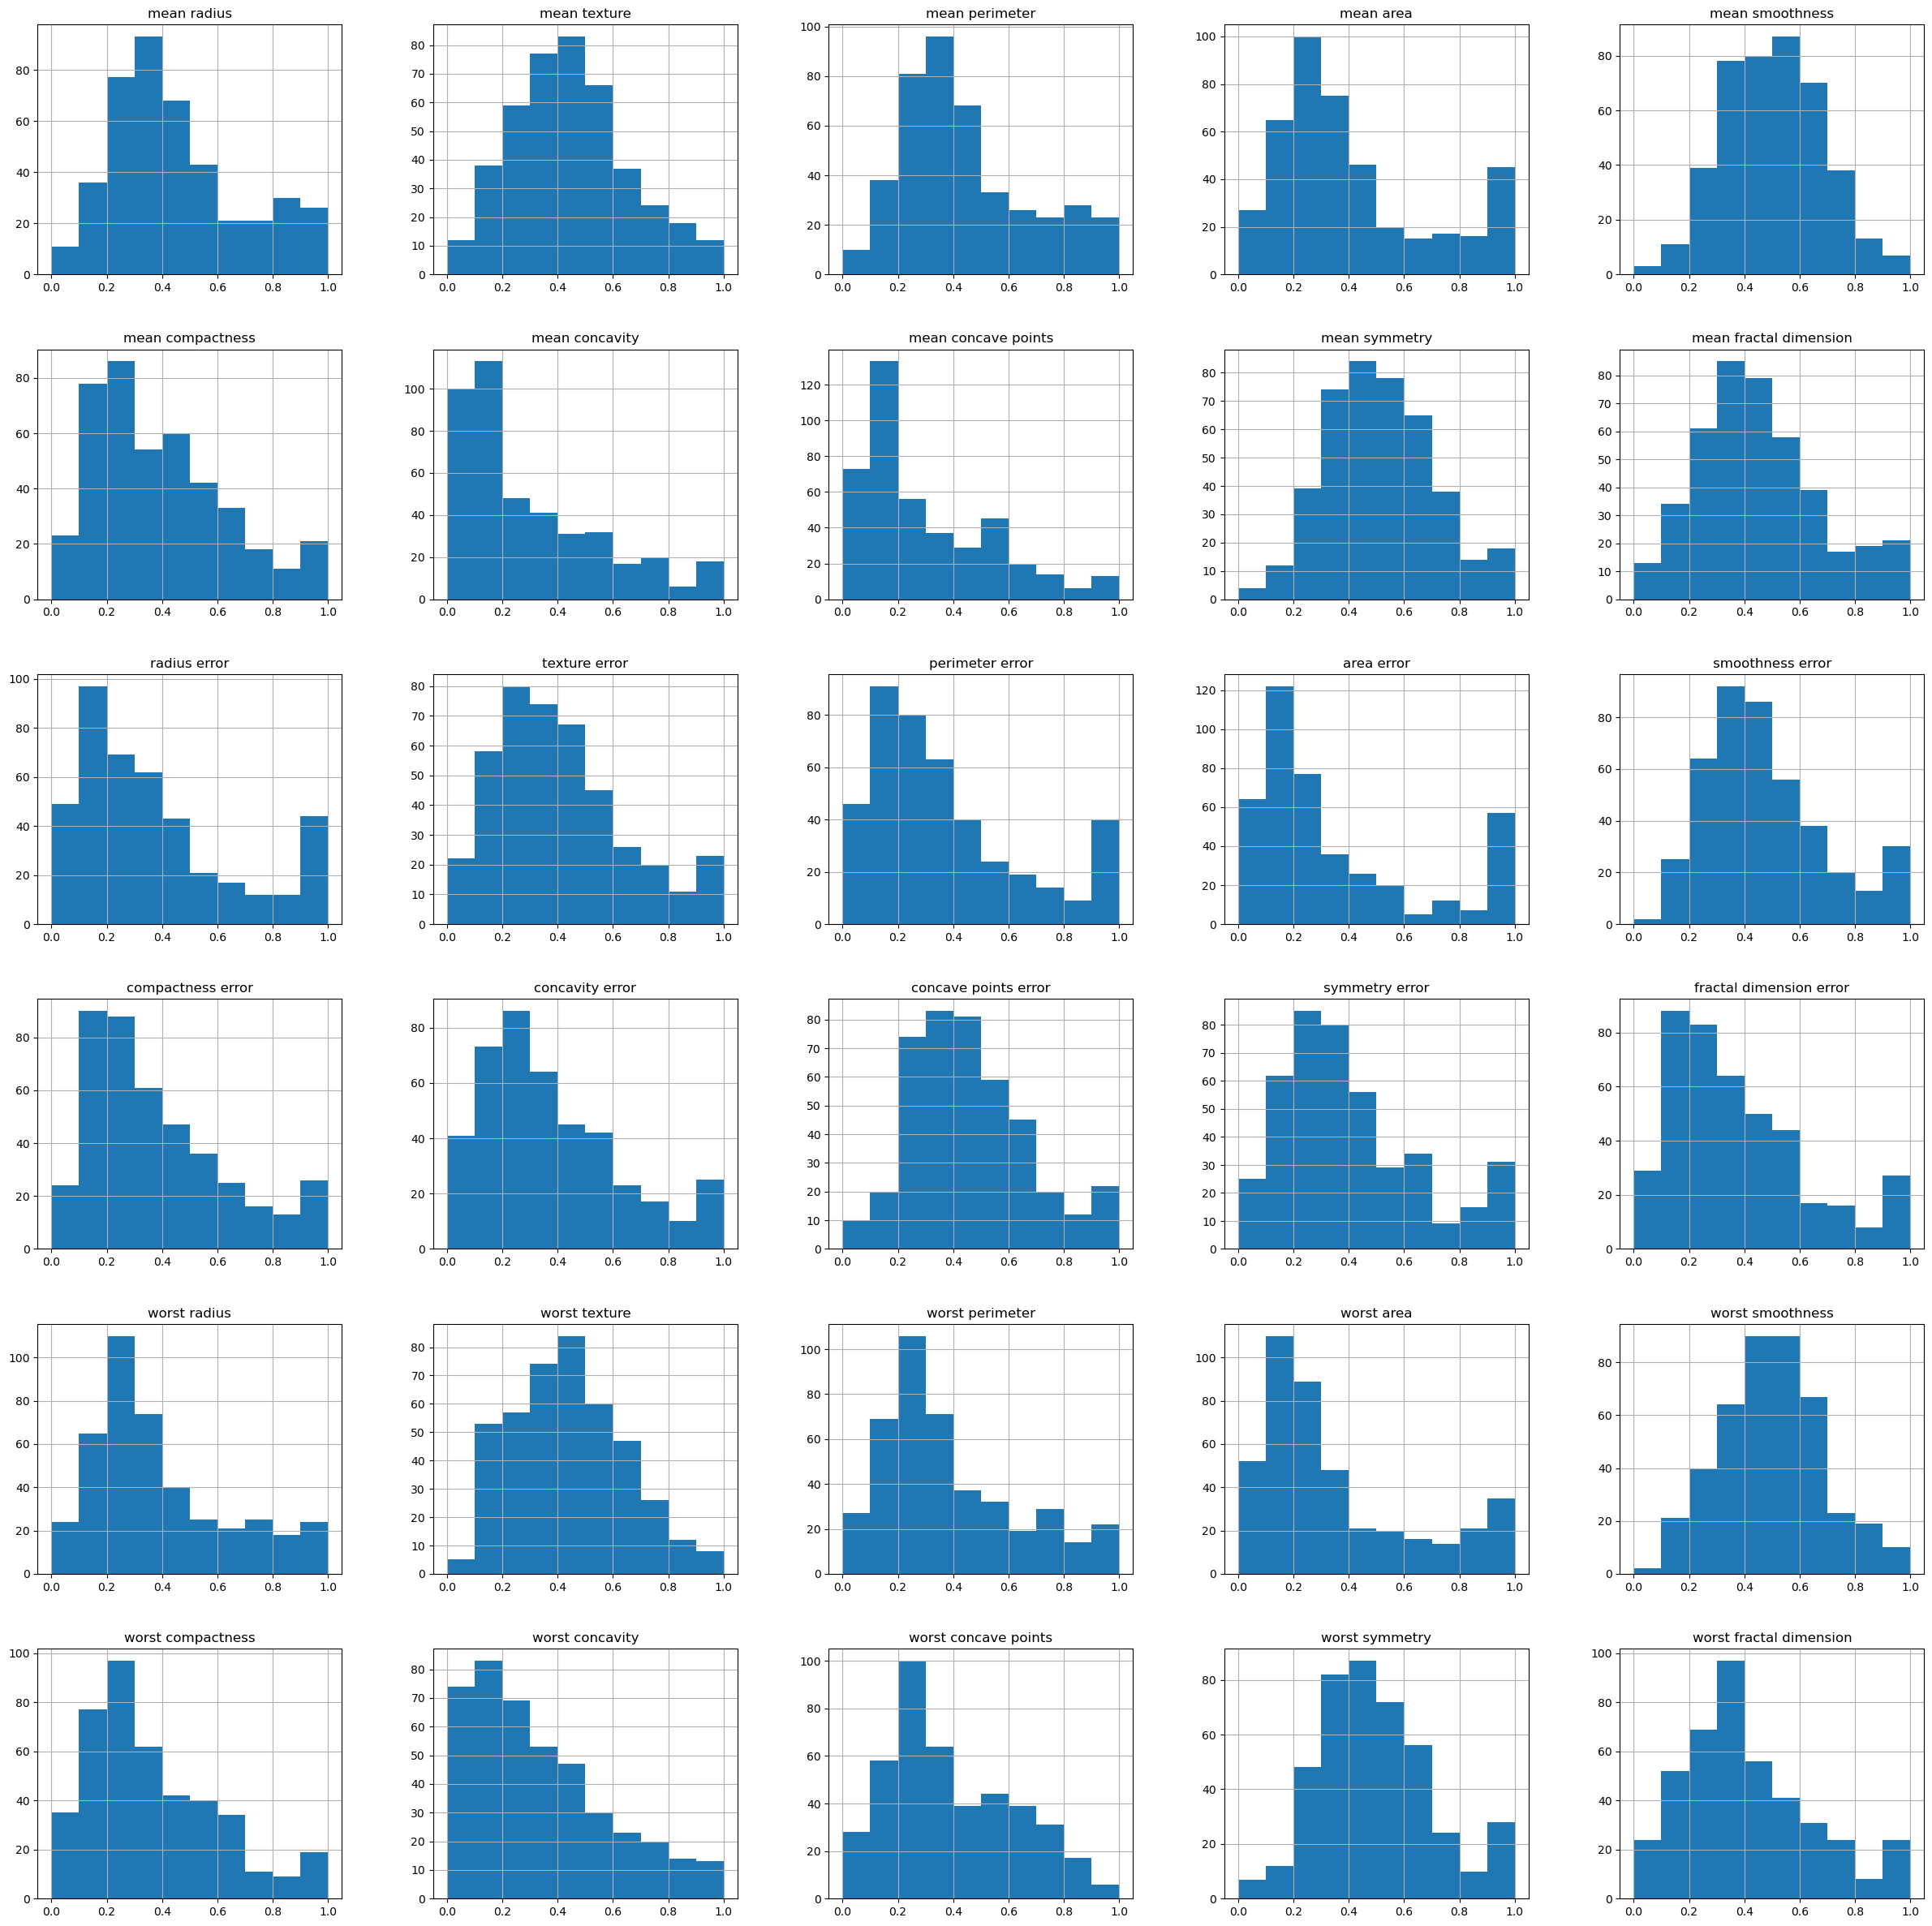

In [25]:
_ = pd.DataFrame(X_train, columns=data.feature_names).hist(figsize=(30, 30))

#### Pomoćna funkcije
Pošto ćemo trenirate više modela, definišemo pomoćnu funkciju za ispisivanje izveštaja klasifikacije.

In [26]:
def report(model, x, y, text = "training"):
    y_pred = model.predict(x)
    
    print("Classification report for model {} on {} data".format(type(model).__name__, text))
    print("---------------------------------------------------------------------------------")
    print(classification_report(y, y_pred, zero_division=True))
    print("---------------------------------------------------------------------------------")
    
    print("Confusion matrix for model {} on {} data ".format(type(model).__name__, text))
    print("---------------------------------------------------------------------------------")
    print(pd.DataFrame(confusion_matrix(y, y_pred), columns=['B', 'M'], index=['B', 'M']))
    print("---------------------------------------------------------------------------------")

### 4. KNN model

### 4.1. Baseline model

Obučavamo model sa podrazumevanim vrednostima hiperparametara.

In [27]:
from sklearn.neighbors import KNeighborsClassifier 

In [28]:
knn_model = KNeighborsClassifier()                     #n_neighbors = k (default 5)

In [29]:
knn_model.fit(X_train, Y_train.values.ravel())         #knn model expects shape of y to be (n_samples, )

KNeighborsClassifier()

Prikazati klasifikacioni izveštaj i matricu konfuzije na trening i test skupu.

In [30]:
report(knn_model, X_train, Y_train)
report(knn_model, X_test, Y_test, "test")

Classification report for model KNeighborsClassifier on training data
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       159
           1       0.97      0.99      0.98       267

    accuracy                           0.97       426
   macro avg       0.98      0.97      0.97       426
weighted avg       0.97      0.97      0.97       426

---------------------------------------------------------------------------------
Confusion matrix for model KNeighborsClassifier on training data 
---------------------------------------------------------------------------------
     B    M
B  151    8
M    3  264
---------------------------------------------------------------------------------
Classification report for model KNeighborsClassifier on test data
---------------------------------------------------------------------------------
              precision  

_Pitanje1_: Da li je došlo do preprilagođavanja?

_Pitanje2_: Koju vrstu grešaka u klasifikaciji želimo da minimizujemo - sa li nam je bitnije da je *FP* ili *FN* malo?

### 4.2. Model za k = 1
Ukoliko klasifikaciju vršimo na osnovu 1 najbližeg suseda, kakav model dobijamo?

In [31]:
model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train, Y_train.values.ravel())

KNeighborsClassifier(n_neighbors=1)

In [32]:
report(model, X_train, Y_train)
report(model, X_test, Y_test, "test")

Classification report for model KNeighborsClassifier on training data
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       159
           1       1.00      1.00      1.00       267

    accuracy                           1.00       426
   macro avg       1.00      1.00      1.00       426
weighted avg       1.00      1.00      1.00       426

---------------------------------------------------------------------------------
Confusion matrix for model KNeighborsClassifier on training data 
---------------------------------------------------------------------------------
     B    M
B  159    0
M    0  267
---------------------------------------------------------------------------------
Classification report for model KNeighborsClassifier on test data
---------------------------------------------------------------------------------
              precision  

Naravno, preciznost na trening skupu je **1** (jer je svaka instanca sama sebi najbliži sused).
Naš model se preprilagodio podacima!

### 4.3. Model za k = veličina trening skupa
Ako je broj suseda na osnovu kojih vršimo klasifikaciju jednak veličini celog skupa za trening, kakav model dobijamo?

In [33]:
model = KNeighborsClassifier(n_neighbors=X_train.shape[0])
model.fit(X_train, Y_train.values.ravel())

KNeighborsClassifier(n_neighbors=426)

In [34]:
report(model, X_train, Y_train)
report(model, X_test, Y_test, "test")

Classification report for model KNeighborsClassifier on training data
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.00      0.00       159
           1       0.63      1.00      0.77       267

    accuracy                           0.63       426
   macro avg       0.81      0.50      0.39       426
weighted avg       0.77      0.63      0.48       426

---------------------------------------------------------------------------------
Confusion matrix for model KNeighborsClassifier on training data 
---------------------------------------------------------------------------------
   B    M
B  0  159
M  0  267
---------------------------------------------------------------------------------
Classification report for model KNeighborsClassifier on test data
---------------------------------------------------------------------------------
              precision    reca

Dobili smo model koji svim instancama predviđa većinsku klasa.

### 5. Podešavanje hiperparametara modela (GridSearchCV)

U mapi čuvamo informaciju o nazivima i vrednostima hiperparametara koje želimo da ispitamo. Želimo da variramo broj najbližih suseda za sve vrednosti iz opsega <code>range(10, 50, 5)</code>, parametar za pridruživanje težina instanci <code>weights</code> (predikcija težinskim glasanjem) za vrednosti *'uniform'* i *'distance'*, kao i parametar <code>p</code> za vrednosti 1 i 2.

In [35]:
params = {'n_neighbors': range(10, 50, 5),
          'weights': ['uniform', 'distance'],
          'p': [1, 2]
         }

In [36]:
estimator = GridSearchCV(KNeighborsClassifier(), params, cv=6)

In [37]:
estimator.fit(X_train, Y_train.values.ravel())

GridSearchCV(cv=6, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(10, 50, 5), 'p': [1, 2],
                         'weights': ['uniform', 'distance']})

Možemo pogledati koja je najbolja kombinacija vrednosti hiperparametara, kao i njemu odgovarajući skor modela:

In [38]:
estimator.best_params_

{'n_neighbors': 10, 'p': 2, 'weights': 'uniform'}

In [39]:
estimator.best_score_

0.9624413145539906

Ispisati klasifikacioni izveštaj i matricu konfuzije najboljeg modela na na test skupu.

In [40]:
report(estimator.best_estimator_, X_test, Y_test, "test")

Classification report for model KNeighborsClassifier on test data
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        53
           1       0.97      0.99      0.98        90

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143

---------------------------------------------------------------------------------
Confusion matrix for model KNeighborsClassifier on test data 
---------------------------------------------------------------------------------
    B   M
B  50   3
M   1  89
---------------------------------------------------------------------------------


## Ansambli

Pravimo ansambl proste agregacije *KNN* modela.

In [41]:
from sklearn.ensemble import BaggingClassifier

In [42]:
bagging_knn = BaggingClassifier(estimator=KNeighborsClassifier(), n_estimators=20, random_state=13)

In [43]:
bagging_knn.fit(X_train, Y_train.values.ravel())         

BaggingClassifier(estimator=KNeighborsClassifier(), n_estimators=20,
                  random_state=13)

Ispisati klasifikacioni izveštaj i matricu konfuzije najboljeg modela na na test skupu.

In [44]:
report(bagging_knn, X_train, Y_train)
report(bagging_knn, X_test, Y_test, "test")    

Classification report for model BaggingClassifier on training data
---------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       159
           1       0.97      0.99      0.98       267

    accuracy                           0.97       426
   macro avg       0.97      0.97      0.97       426
weighted avg       0.97      0.97      0.97       426

---------------------------------------------------------------------------------
Confusion matrix for model BaggingClassifier on training data 
---------------------------------------------------------------------------------
     B    M
B  150    9
M    3  264
---------------------------------------------------------------------------------
Classification report for model BaggingClassifier on test data
---------------------------------------------------------------------------------
              precision    recall 

## Poređenje dobijenih modela

Napravili smo više modela, sada je pitanje koji od njih najbolje rešava problem klasifikacije. Naravno, ne možemo zaključiti samo na osnovu preciznosti modela. 
Za poređenje koristimo **F1 skor**.

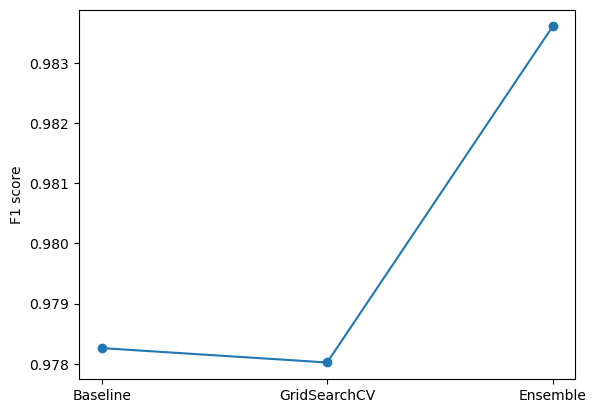

In [45]:
models = [knn_model, estimator.best_estimator_, bagging_knn]
model_names = ['Baseline', 'GridSearchCV', 'Ensemble']
model_f1 = []

for model in models:
    Y_test_pred = model.predict(X_test)
    f1 = f1_score(Y_test, Y_test_pred)
    model_f1.append(f1)
    
plt.scatter(range(len(model_f1)), model_f1)    
plt.plot(range(len(model_f1)), model_f1)
plt.xticks(range(len(model_f1)), model_names)
plt.ylabel('F1 score')
plt.show()

Koji model izabrati? Koje su prednosti/mane ovih modela?

### Za vežbu:
* Pokušajte da poboljšate model finijim podešavanjem hiperparametara
* Uporediti dobijene modele sa modelima zasnovanim na Stablima odlučivanja. Koje su prednosti/mane *KNN* modela u odnosu na stabla odlučivanja?